# 01 - Análise Exploratória: Impacto Climático na Agricultura do Sudeste

## Objetivo
Explorar os dados de produção agrícola das principais culturas do Sudeste brasileiro (2013-2023) e investigar a relação com variáveis climáticas.

## Dataset
- **Período**: 2013 a 2023 (11 anos)
- **Região**: Sudeste (SP, MG, RJ, ES)
- **Culturas**: Café, Cana-de-açúcar, Laranja, Milho
- **Variáveis Climáticas**: Temperatura média (°C), Precipitação total (mm), Dias secos consecutivos (CDD)

---



## 1. Carregando o dataset


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
#index_col=0 impede que o pandas crie uma coluna extra de índice
df = pd.read_csv('agro_clima.csv', index_col=0)
df.head()

,Região,Cultura,Quantidade_Produzida_Toneladas,CDD_dias_secos_consecutivos,Precipitacao_Total_mm,Temperatura_Media_C
Ano,,,,,,
2013,Sudeste,Café (em grão) Total,2595105.0,42.75,1873.10,25.53
2013,Sudeste,Cana-de-açúcar,514623424.0,42.75,1873.10,25.53
2013,Sudeste,Laranja,13989589.0,42.75,1873.10,25.53
2013,Sudeste,Milho (em grão),11932192.0,42.75,1873.10,25.53
2014,Sudeste,Café (em grão) Total,2445657.0,42.27,1758.39,25.70


## 2. Estrutura do Dataset

Verificando tipos de dados, valores ausentes e dimensões.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, 2013 to 2023
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Região                          44 non-null     object 
 1   Cultura                         44 non-null     object 
 2   Quantidade_Produzida_Toneladas  44 non-null     float64
 3   CDD_dias_secos_consecutivos     44 non-null     float64
 4   Precipitacao_Total_mm           44 non-null     float64
 5   Temperatura_Media_C             44 non-null     float64
dtypes: float64(4), object(2)
memory usage: 2.4+ KB


In [3]:
df.isnull().sum()

,0
Região,0
Cultura,0
Quantidade_Produzida_Toneladas,0
CDD_dias_secos_consecutivos,0
Precipitacao_Total_mm,0
Temperatura_Media_C,0


## 3. Estatísticas Descritivas

Resumo estatístico das variáveis numéricas do dataset.

In [4]:
df.describe()

,Quantidade_Produzida_Toneladas,CDD_dias_secos_consecutivos,Precipitacao_Total_mm,Temperatura_Media_C
count,4.400000e+01,44.000000,44.000000,44.000000
mean,1.336967e+08,52.978182,1706.274545,25.729091
std,2.178374e+08,6.278680,112.515093,0.172719
min,2.237579e+06,42.270000,1428.390000,25.480000
25%,8.667814e+06,49.820000,1666.410000,25.540000
50%,1.328326e+07,53.190000,1741.580000,25.740000
75%,1.312680e+08,57.650000,1771.780000,25.910000
max,5.271195e+08,62.390000,1873.100000,25.990000


## 5. Análise Exploratória Inicial


In [5]:
df.groupby('Cultura')['Quantidade_Produzida_Toneladas'].sum().sort_values(ascending=False)

,Quantidade_Produzida_Toneladas
Cultura,
Cana-de-açúcar,5.570325e+09
Laranja,1.539216e+08
Milho (em grão),1.291690e+08
Café (em grão) Total,2.924086e+07


In [6]:
df.groupby(['Ano'])['Quantidade_Produzida_Toneladas'].sum().sort_values(ascending=False)

,Quantidade_Produzida_Toneladas
Ano,
2023,558116191.0
2017,553674602.0
2020,544550201.0
2016,544508739.0
2013,543140310.0
2018,534435899.0
2019,532843631.0
2022,529416536.0
2015,526836899.0


## 6. Visualizações


### 6.1 Evolução dos Dias Secos Consecutivos (CDD)

Períodos de estiagem prolongada são críticos para a agricultura. Vamos visualizar como o CDD (Consecutive Dry Days) variou ao longo dos anos.

In [7]:
dfplot1 = df.groupby(['Ano'])['CDD_dias_secos_consecutivos'].mean().reset_index()
dfplot1.head()

,Ano,CDD_dias_secos_consecutivos
0,2013,42.75
1,2014,42.27
2,2015,53.19
3,2016,51.38
4,2017,61.46


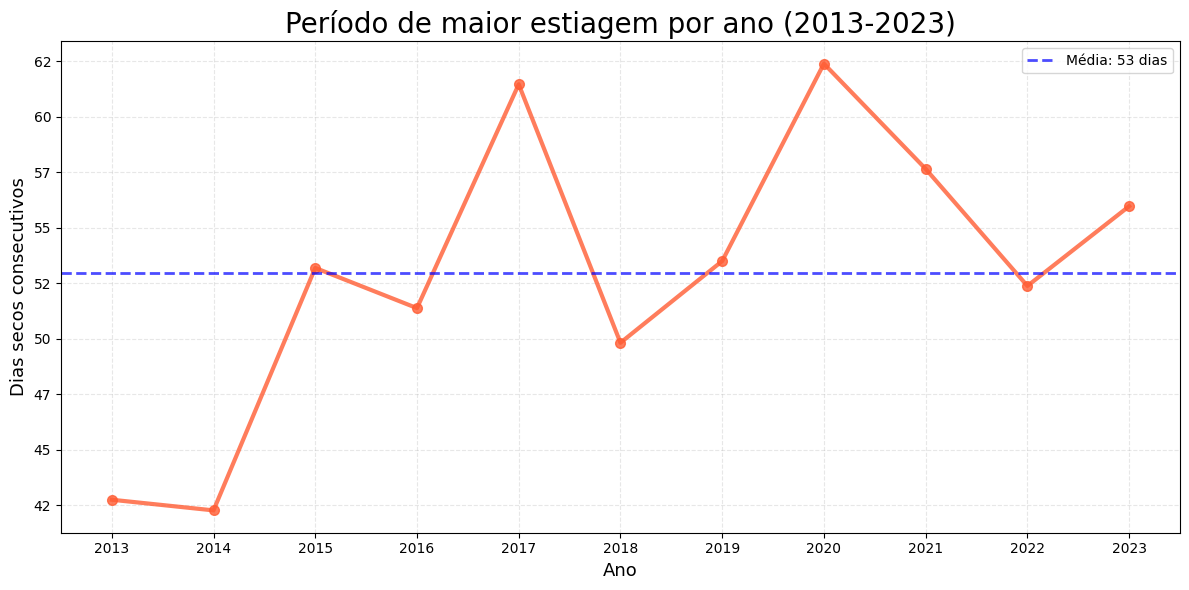

In [8]:
from matplotlib.ticker import FuncFormatter

def formatar_inteiro(x, pos):
    return f'{int(x)}'

media_cdd = dfplot1['CDD_dias_secos_consecutivos'].mean()

plt.figure(figsize=(12, 6))
plt.plot(dfplot1['Ano'], dfplot1['CDD_dias_secos_consecutivos'],
         marker='o',
         linewidth=3,
         markersize=7,
         color='#ff5c33',
         alpha=0.8)

plt.title('Período de maior estiagem por ano (2013-2023)', fontsize=20)
plt.xlabel('Ano', fontsize=13)
plt.ylabel('Dias secos consecutivos', fontsize=13)

plt.axhline(y=media_cdd, color='blue', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Média: {media_cdd:.0f} dias')

plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(dfplot1['Ano'])
plt.gca().yaxis.set_major_formatter(FuncFormatter(formatar_inteiro))
plt.legend()
plt.tight_layout()
plt.show()

### 6.2 Evolução da Temperatura Média

Análise da variação térmica no Sudeste brasileiro ao longo da última década.

In [9]:
dfplot2 = df.groupby(['Ano'])['Temperatura_Media_C'].mean().reset_index()
dfplot2.head()

,Ano,Temperatura_Media_C
0,2013,25.53
1,2014,25.70
2,2015,25.99
3,2016,25.78
4,2017,25.74


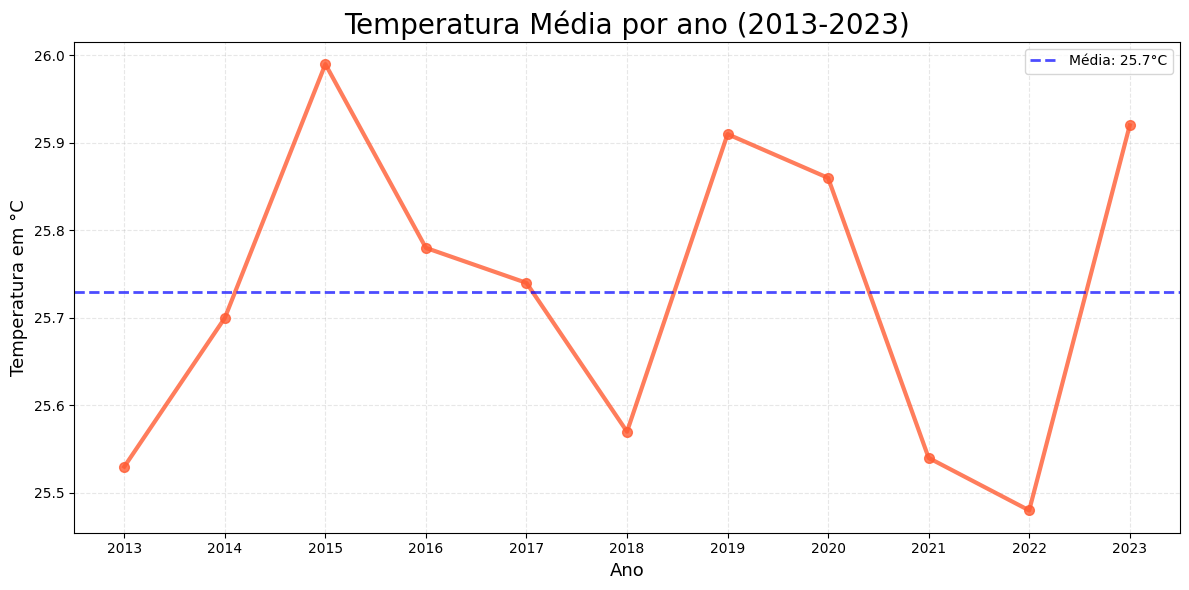

In [10]:
media_cdd = dfplot2['Temperatura_Media_C'].mean()

plt.figure(figsize=(12, 6))
plt.plot(dfplot2['Ano'], dfplot2['Temperatura_Media_C'],
         marker='o',
         linewidth=3,
         markersize=7,
         color='#ff5c33',
         alpha=0.8)

plt.title('Temperatura Média por ano (2013-2023)', fontsize=20)
plt.xlabel('Ano', fontsize=13)
plt.ylabel('Temperatura em °C', fontsize=13)

plt.axhline(y=media_cdd, color='blue', linestyle='--', linewidth=2, alpha=0.7,
            label=f'Média: {media_cdd:.1f}°C')

plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(dfplot2['Ano'])
plt.legend()
plt.tight_layout()
plt.show()

## 7. Principais Insights da Análise Exploratória

### Produção Agrícola

**Cana-de-açúcar** domina completamente a produção do Sudeste em volume, representando mais de 5 bilhões de toneladas no período 2013-2023, seguida de longe por **Laranja** (aproximadamente 154 milhões de toneladas) e **Café** (29 milhões de toneladas). Isso reflete a importância econômica da cana no Sudeste para produção de etanol e açúcar.

### Variáveis Climáticas

**Dias Secos Consecutivos (CDD)**:
- Média histórica de 53 dias secos consecutivos
- Pico de estiagem em 2020 (62 dias) e 2017 (61 dias)
- Anos mais úmidos: 2013 e 2014 (aproximadamente 42 dias)
- Tendência aparente de aumento na variabilidade climática nos últimos anos
- Períodos prolongados de seca podem impactar diretamente a produtividade, especialmente de culturas sensíveis como café e milho

**Temperatura Média**:
- Temperatura média do período: 25,7°C
- Ano mais quente: 2015 (26,0°C)
- Ano mais frio: 2022 (25,5°C)
- Amplitude térmica de apenas 0,5°C indica relativa estabilidade térmica no período
- Temperaturas ligeiramente acima da média observadas em 2015, 2019 e 2023

### Observações Gerais

A análise inicial revela que o Sudeste brasileiro apresenta:
1. Produção agrícola altamente concentrada em cana-de-açúcar
2. Temperatura relativamente estável ao longo da última década
3. Variabilidade significativa nos períodos de estiagem (CDD)
4. Anos extremos de seca (2017, 2020) que merecem análise mais aprofundada de impacto na produção